In [5]:
import os
import zipfile
import pandas as pd

# Path to your downloaded LA compressed file
LA_ZIP = r"C:\Users\jaswa\Downloads\LA.zip"
# Check that the file exists
if os.path.exists(LA_ZIP):
    print("LA dataset found successfully.")
    print("File size:", round(os.path.getsize(LA_ZIP) / (1024**3), 2), "GB")
else:
    print("LA dataset not found.")
    print("Check the path in LA_ZIP.")

LA dataset found successfully.
File size: 7.12 GB


In [7]:
with zipfile.ZipFile(LA_ZIP, 'r') as zip_ref:
    files = zip_ref.namelist()

print("Total files/folders in LA archive:", len(files))

print("\nFirst 30 entries:")
for file in files[:30]:
    print(file)

Total files/folders in LA archive: 122328

First 30 entries:
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trl.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trl.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trl.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.txt
LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt
LA/ASVspoof2019_LA_asv_protocols/
LA/ASVspoof2019_LA_train/flac/LA_T_3653923.flac
LA/ASVspoof2019_LA_train/flac/LA_T_9203016.flac
LA/ASVspoof2019_LA_train/flac/LA_T_7555561.flac
LA/ASVspoof2019_LA_train/flac/LA_T_5726173.flac
LA/A

In [9]:
# Find protocol files related to the LA training dataset

protocol_files = [
    file for file in files
    if "ASVspoof2019_LA_cm_protocols" in file
    and file.lower().endswith(".txt")
]

print("Protocol files found:")
for file in protocol_files:
    print(file)

Protocol files found:
LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt


In [11]:
# Training protocol file
TRAIN_PROTOCOL = (
    "LA/ASVspoof2019_LA_cm_protocols/"
    "ASVspoof2019.LA.cm.train.trn.txt"
)

# Read the protocol directly from the ZIP file
with zipfile.ZipFile(LA_ZIP, 'r') as zip_ref:
    with zip_ref.open(TRAIN_PROTOCOL) as f:
        protocol = pd.read_csv(
            f,
            sep=r"\s+",
            header=None
        )

print("Number of training samples:", len(protocol))

print("\nFirst 5 rows:")
print(protocol.head())

Number of training samples: 25380

First 5 rows:
         0             1  2  3         4
0  LA_0079  LA_T_1138215  -  -  bonafide
1  LA_0079  LA_T_1271820  -  -  bonafide
2  LA_0079  LA_T_1272637  -  -  bonafide
3  LA_0079  LA_T_1276960  -  -  bonafide
4  LA_0079  LA_T_1341447  -  -  bonafide


In [13]:
# Give meaningful column names
protocol.columns = [
    "speaker_id",
    "audio_id",
    "attack_id",
    "unused",
    "label"
]

# Check the two classes
print("Class distribution:")
print(protocol["label"].value_counts())

print("\nUnique classes:")
print(protocol["label"].unique())

Class distribution:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Unique classes:
['bonafide' 'spoof']


In [17]:
# Select equal numbers from both classes

bonafide_data = protocol[
    protocol["label"] == "bonafide"
].sample(
    n=2000,
    random_state=42
)

spoof_data = protocol[
    protocol["label"] == "spoof"
].sample(
    n=2000,
    random_state=42
)

# Combine the two classes
project_data = pd.concat(
    [bonafide_data, spoof_data],
    ignore_index=True
)

# Shuffle the dataset
project_data = project_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Project dataset size:", len(project_data))

print("\nClass distribution:")
print(project_data["label"].value_counts())

print("\nFirst 5 samples:")
print(project_data.head())

Project dataset size: 4000

Class distribution:
label
bonafide    2000
spoof       2000
Name: count, dtype: int64

First 5 samples:
  speaker_id      audio_id attack_id unused     label
0    LA_0084  LA_T_8571358         -      -  bonafide
1    LA_0083  LA_T_1093716         -    A03     spoof
2    LA_0097  LA_T_3993498         -      -  bonafide
3    LA_0082  LA_T_9219701         -    A03     spoof
4    LA_0096  LA_T_7465398         -    A03     spoof


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

# Encoding
def encode_data(data):
    encoded_data = data.copy()

    speaker_mapping = {
        value: index
        for index, value in enumerate(
            encoded_data["speaker_id"].unique()
        )
    }

    attack_mapping = {
        value: index
        for index, value in enumerate(
            encoded_data["attack_id"].unique()
        )
    }

    encoded_data["speaker_id"] = encoded_data["speaker_id"].map(
        speaker_mapping
    )

    encoded_data["attack_id"] = encoded_data["attack_id"].map(
        attack_mapping
    )

    return encoded_data


# Imputation
def impute_missing_values(data, method="mean"):
    data = data.copy()

    for column in data.columns:

        if data[column].isnull().sum() > 0:

            if method == "mean":
                data[column] = data[column].fillna(
                    data[column].mean()
                )

            elif method == "median":
                data[column] = data[column].fillna(
                    data[column].median()
                )

            elif method == "mode":
                data[column] = data[column].fillna(
                    data[column].mode()[0]
                )

    return data


# Euclidean distance
def calculate_euclidean_distance(point1, point2):
    point1 = np.array(point1, dtype=float)
    point2 = np.array(point2, dtype=float)

    return np.sqrt(
        np.sum((point1 - point2) ** 2)
    )


# Bubble sort
def bubble_sort(distances):
    arr = distances.copy()

    for i in range(len(arr)):

        for j in range(len(arr) - i - 1):

            if arr[j][1] > arr[j + 1][1]:

                arr[j], arr[j + 1] = (
                    arr[j + 1],
                    arr[j]
                )

    return arr


# Selection sort
def selection_sort(distances):
    arr = distances.copy()

    for i in range(len(arr)):

        min_index = i

        for j in range(i + 1, len(arr)):

            if arr[j][1] < arr[min_index][1]:
                min_index = j

        arr[i], arr[min_index] = (
            arr[min_index],
            arr[i]
        )

    return arr


# Insertion sort
def insertion_sort(distances):
    arr = distances.copy()

    for i in range(1, len(arr)):

        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j][1] > key[1]:

            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

    return arr


# Sorting configuration
sorting_algorithms = {
    "bubble": bubble_sort,
    "selection": selection_sort,
    "insertion": insertion_sort
}


# Find k nearest neighbors
def identify_neighbors(
    X_train,
    y_train,
    test_point,
    k=3,
    sort_method="bubble"
):

    distances = []

    for i in range(len(X_train)):

        distance = calculate_euclidean_distance(
            X_train.iloc[i],
            test_point
        )

        distances.append(
            (i, distance, y_train.iloc[i])
        )

    sorted_distances = sorting_algorithms[
        sort_method
    ](distances)

    return sorted_distances[:k]


# Majority voting
def majority_vote(neighbors):

    labels = [
        neighbor[2]
        for neighbor in neighbors
    ]

    counts = Counter(labels)

    max_votes = max(counts.values())

    candidates = [
        label
        for label, count in counts.items()
        if count == max_votes
    ]

    # Tie breaking
    if len(candidates) > 1:

        for neighbor in neighbors:

            if neighbor[2] in candidates:
                return neighbor[2]

    return candidates[0]


# kNN prediction
def knn_predict(
    X_train,
    y_train,
    X_test,
    k=3,
    sort_method="bubble"
):

    predictions = []

    for i in range(len(X_test)):

        neighbors = identify_neighbors(
            X_train,
            y_train,
            X_test.iloc[i],
            k,
            sort_method
        )

        prediction = majority_vote(
            neighbors
        )

        predictions.append(prediction)

    return np.array(predictions)


# Use project dataset
data = project_data.copy()

print("Project dataset size:", len(data))

print("\nClass distribution:")
print(data["label"].value_counts())


# Encoding
encoded_data = encode_data(data)

print("\nEncoding completed.")


# Select features and target
X = encoded_data[
    ["speaker_id", "attack_id"]
].copy()

y = encoded_data["label"].copy()


# Imputation
X = impute_missing_values(
    X,
    method="mean"
)

print("Imputation completed.")

print("\nFeature shape:", X.shape)


# Use a small dataset for A1 demonstration
X_train = X.iloc[:1000].reset_index(drop=True)
y_train = y.iloc[:1000].reset_index(drop=True)

X_test = X.iloc[1000:1100].reset_index(drop=True)
y_test = y.iloc[1000:1100].reset_index(drop=True)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# Set k and sorting algorithm
k = 3
sort_method = "bubble"

print("\nSorting algorithm:", sort_method)
print("k:", k)


# Predict
predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    k,
    sort_method
)

print("\nPrediction completed.")


# Accuracy
accuracy = np.mean(
    predictions == y_test.values
)

print("\nAccuracy:", accuracy)

print("\nFirst 10 actual values:")
print(y_test.values[:10])

print("\nFirst 10 predicted values:")
print(predictions[:10])

In [24]:
print("HELLO")

HELLO


In [26]:
print("Project dataset size:", len(project_data))
print(project_data.head())

Project dataset size: 4000
  speaker_id      audio_id attack_id unused     label
0    LA_0084  LA_T_8571358         -      -  bonafide
1    LA_0083  LA_T_1093716         -    A03     spoof
2    LA_0097  LA_T_3993498         -      -  bonafide
3    LA_0082  LA_T_9219701         -    A03     spoof
4    LA_0096  LA_T_7465398         -    A03     spoof


In [28]:
# Test encoding

encoded_data = project_data.copy()

encoded_data["speaker_id"] = pd.factorize(
    encoded_data["speaker_id"]
)[0]

encoded_data["attack_id"] = pd.factorize(
    encoded_data["attack_id"]
)[0]

X = encoded_data[
    ["speaker_id", "attack_id"]
].copy()

y = encoded_data["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (4000, 2)
y shape: (4000,)

X:
   speaker_id  attack_id
0           0          0
1           1          0
2           2          0
3           3          0
4           4          0

y:
0    bonafide
1       spoof
2    bonafide
3       spoof
4       spoof
Name: label, dtype: object


In [30]:
# Distance calculation
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))


# Bubble sort
def bubble_sort(distances):
    distances = distances.copy()

    for i in range(len(distances)):
        for j in range(len(distances) - i - 1):

            if distances[j][1] > distances[j + 1][1]:
                distances[j], distances[j + 1] = (
                    distances[j + 1],
                    distances[j]
                )

    return distances


# Selection sort
def selection_sort(distances):
    distances = distances.copy()

    for i in range(len(distances)):

        min_index = i

        for j in range(i + 1, len(distances)):

            if distances[j][1] < distances[min_index][1]:
                min_index = j

        distances[i], distances[min_index] = (
            distances[min_index],
            distances[i]
        )

    return distances


# Insertion sort
def insertion_sort(distances):
    distances = distances.copy()

    for i in range(1, len(distances)):

        key = distances[i]
        j = i - 1

        while j >= 0 and distances[j][1] > key[1]:
            distances[j + 1] = distances[j]
            j -= 1

        distances[j + 1] = key

    return distances


# Select sorting algorithm
sorting_algorithms = {
    "bubble": bubble_sort,
    "selection": selection_sort,
    "insertion": insertion_sort
}


# Find k nearest neighbors
def find_neighbors(X_train, y_train, test_point, k=3,
                   sort_method="bubble"):

    distances = []

    for i in range(len(X_train)):

        distance = euclidean_distance(
            X_train[i],
            test_point
        )

        distances.append(
            (i, distance, y_train[i])
        )

    distances = sorting_algorithms[sort_method](
        distances
    )

    return distances[:k]


# Majority voting
def majority_vote(neighbors):

    votes = {}

    for neighbor in neighbors:

        label = neighbor[2]

        votes[label] = votes.get(label, 0) + 1

    max_votes = max(votes.values())

    winners = [
        label
        for label, count in votes.items()
        if count == max_votes
    ]

    # Tie breaking
    if len(winners) == 1:
        return winners[0]

    return neighbors[0][2]


# kNN prediction
def my_knn_predict(X_train, y_train, X_test,
                   k=3, sort_method="bubble"):

    predictions = []

    X_train = X_train.to_numpy()
    y_train = y_train.to_numpy()
    X_test = X_test.to_numpy()

    for test_point in X_test:

        neighbors = find_neighbors(
            X_train,
            y_train,
            test_point,
            k,
            sort_method
        )

        prediction = majority_vote(neighbors)

        predictions.append(prediction)

    return np.array(predictions)


# Use a small subset for manual kNN
X_train_a1 = X.iloc[:200]
y_train_a1 = y.iloc[:200]

X_test_a1 = X.iloc[200:220]
y_test_a1 = y.iloc[200:220]

print("Training samples:", len(X_train_a1))
print("Testing samples:", len(X_test_a1))


# Run our kNN
predictions_a1 = my_knn_predict(
    X_train_a1,
    y_train_a1,
    X_test_a1,
    k=3,
    sort_method="bubble"
)


# Calculate accuracy
accuracy_a1 = np.mean(
    predictions_a1 == y_test_a1.to_numpy()
)

print("k =", 3)
print("Sorting algorithm =", "bubble")
print("Accuracy =", accuracy_a1)

print("\nActual:")
print(y_test_a1.to_numpy())

print("\nPredicted:")
print(predictions_a1)

Training samples: 200
Testing samples: 20
k = 3
Sorting algorithm = bubble
Accuracy = 0.35

Actual:
['spoof' 'spoof' 'bonafide' 'spoof' 'spoof' 'bonafide' 'bonafide' 'spoof'
 'spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'spoof' 'bonafide'
 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof']

Predicted:
['spoof' 'bonafide' 'spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'spoof'
 'bonafide' 'bonafide' 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof'
 'spoof' 'bonafide' 'spoof' 'spoof' 'bonafide']


In [32]:
# Weighted voting
def weighted_vote(neighbors):

    weights = {}

    for index, distance, label in neighbors:

        weight = 1 / (distance + 1e-10)

        if label not in weights:
            weights[label] = 0

        weights[label] += weight

    max_weight = max(weights.values())

    winners = [
        label
        for label, weight in weights.items()
        if weight == max_weight
    ]

    # Tie breaking
    if len(winners) == 1:
        return winners[0]

    return neighbors[0][2]


# Weighted kNN prediction
def weighted_knn_predict(
    X_train,
    y_train,
    X_test,
    k=3,
    sort_method="bubble"
):

    predictions = []

    X_train = X_train.to_numpy()
    y_train = y_train.to_numpy()
    X_test = X_test.to_numpy()

    for test_point in X_test:

        neighbors = find_neighbors(
            X_train,
            y_train,
            test_point,
            k,
            sort_method
        )

        prediction = weighted_vote(neighbors)

        predictions.append(prediction)

    return np.array(predictions)


# Run weighted kNN
weighted_predictions = weighted_knn_predict(
    X_train_a1,
    y_train_a1,
    X_test_a1,
    k=3,
    sort_method="bubble"
)


# Calculate accuracy
weighted_accuracy = np.mean(
    weighted_predictions == y_test_a1.to_numpy()
)

print("Weighted kNN")
print("k =", 3)
print("Sorting algorithm =", "bubble")
print("Accuracy =", weighted_accuracy)

print("\nActual:")
print(y_test_a1.to_numpy())

print("\nPredicted:")
print(weighted_predictions)

Weighted kNN
k = 3
Sorting algorithm = bubble
Accuracy = 0.35

Actual:
['spoof' 'spoof' 'bonafide' 'spoof' 'spoof' 'bonafide' 'bonafide' 'spoof'
 'spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'spoof' 'bonafide'
 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof']

Predicted:
['spoof' 'bonafide' 'spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'spoof'
 'bonafide' 'bonafide' 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof'
 'spoof' 'bonafide' 'spoof' 'spoof' 'bonafide']


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Total samples: 4000
Training samples: 2800
Testing samples: 1200

Training class distribution:
label
bonafide    1400
spoof       1400
Name: count, dtype: int64

Testing class distribution:
label
bonafide    600
spoof       600
Name: count, dtype: int64


In [36]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(
    n_neighbors=3
)

neigh.fit(
    X_train,
    y_train
)

print("kNN classifier trained successfully.")
print("Number of neighbors (k):", 3)

kNN classifier trained successfully.
Number of neighbors (k): 3


In [38]:
accuracy = neigh.score(
    X_test,
    y_test
)

print("Accuracy of kNN:", accuracy)

Accuracy of kNN: 0.52


In [40]:
predictions = neigh.predict(X_test)

print("Predictions:")
print(predictions)

print("\nFirst 20 predictions:")
print(predictions[:20])

print("\nActual values:")
print(y_test.values[:20])

Predictions:
['bonafide' 'bonafide' 'bonafide' ... 'spoof' 'bonafide' 'bonafide']

First 20 predictions:
['bonafide' 'bonafide' 'bonafide' 'spoof' 'bonafide' 'spoof' 'spoof'
 'spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof'
 'bonafide' 'spoof' 'bonafide' 'bonafide' 'spoof' 'bonafide']

Actual values:
['bonafide' 'spoof' 'spoof' 'bonafide' 'spoof' 'spoof' 'spoof' 'spoof'
 'spoof' 'bonafide' 'spoof' 'bonafide' 'bonafide' 'bonafide' 'bonafide'
 'spoof' 'bonafide' 'bonafide' 'bonafide' 'spoof']


In [44]:
class MyKNN:

    def __init__(self, k=3, sort_method="bubble", weighted=False):
        self.k = k
        self.sort_method = sort_method
        self.weighted = weighted

    def fit(self, X, y):
        self.X_train = X.reset_index(drop=True)
        self.y_train = y.reset_index(drop=True)

    def predict(self, X):

        if self.weighted:
            return weighted_knn_predict(
                self.X_train,
                self.y_train,
                X.reset_index(drop=True),
                self.k,
                self.sort_method
            )

        return my_knn_predict(
            self.X_train,
            self.y_train,
            X.reset_index(drop=True),
            self.k,
            self.sort_method
        )

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(
            predictions == y.reset_index(drop=True).to_numpy()
        )


# Use a small subset for testing our implementation
X_train_a7 = X_train.iloc[:200].copy()
y_train_a7 = y_train.iloc[:200].copy()

X_test_a7 = X_test.iloc[:20].copy()
y_test_a7 = y_test.iloc[:20].copy()


# Create model
my_knn = MyKNN(
    k=3,
    sort_method="bubble"
)

# Fit
my_knn.fit(
    X_train_a7,
    y_train_a7
)

# Predict
my_predictions = my_knn.predict(
    X_test_a7
)

# Score
my_accuracy = my_knn.score(
    X_test_a7,
    y_test_a7
)

print("Our kNN")
print("k =", 3)
print("Sorting algorithm =", "bubble")
print("Training samples =", len(X_train_a7))
print("Testing samples =", len(X_test_a7))
print("Accuracy =", my_accuracy)

print("\nPredictions:")
print(my_predictions)

print("\nActual:")
print(y_test_a7.to_numpy())

Our kNN
k = 3
Sorting algorithm = bubble
Training samples = 200
Testing samples = 20
Accuracy = 0.55

Predictions:
['spoof' 'bonafide' 'bonafide' 'spoof' 'spoof' 'spoof' 'spoof' 'spoof'
 'spoof' 'bonafide' 'spoof' 'bonafide' 'spoof' 'spoof' 'bonafide' 'spoof'
 'bonafide' 'spoof' 'spoof' 'bonafide']

Actual:
['bonafide' 'spoof' 'spoof' 'bonafide' 'spoof' 'spoof' 'spoof' 'spoof'
 'spoof' 'bonafide' 'spoof' 'bonafide' 'bonafide' 'bonafide' 'bonafide'
 'spoof' 'bonafide' 'bonafide' 'bonafide' 'spoof']


   k  Our kNN  Sklearn kNN
0  1     0.35         0.35
1  3     0.55         0.45
2  5     0.45         0.35
3  7     0.50         0.35
4  9     0.60         0.40


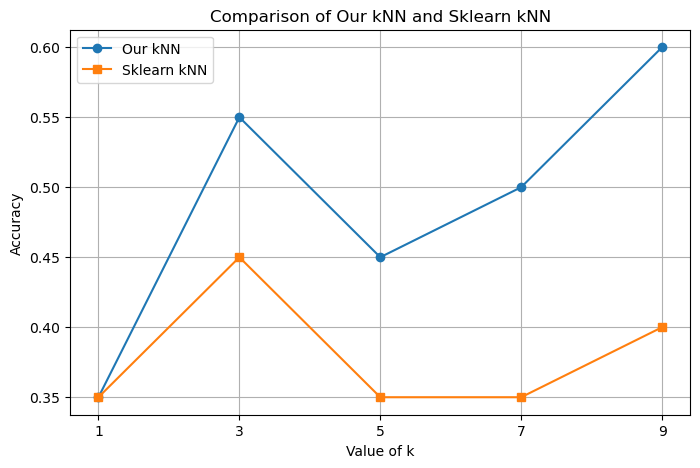

In [46]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Use a small dataset for comparison
X_train_a8 = X_train.iloc[:200].copy()
y_train_a8 = y_train.iloc[:200].copy()

X_test_a8 = X_test.iloc[:20].copy()
y_test_a8 = y_test.iloc[:20].copy()

k_values = [1, 3, 5, 7, 9]

my_accuracies = []
sklearn_accuracies = []

for k in k_values:

    # Our kNN
    my_model = MyKNN(
        k=k,
        sort_method="bubble"
    )

    my_model.fit(
        X_train_a8,
        y_train_a8
    )

    my_accuracy = my_model.score(
        X_test_a8,
        y_test_a8
    )

    my_accuracies.append(my_accuracy)

    # Sklearn kNN
    sklearn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    sklearn_model.fit(
        X_train_a8,
        y_train_a8
    )

    sklearn_accuracy = sklearn_model.score(
        X_test_a8,
        y_test_a8
    )

    sklearn_accuracies.append(
        sklearn_accuracy
    )


# Display results
results = pd.DataFrame({
    "k": k_values,
    "Our kNN": my_accuracies,
    "Sklearn kNN": sklearn_accuracies
})

print(results)


# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    my_accuracies,
    marker="o",
    label="Our kNN"
)

plt.plot(
    k_values,
    sklearn_accuracies,
    marker="s",
    label="Sklearn kNN"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("Comparison of Our kNN and Sklearn kNN")

plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()